In [ ]:
from data import get_loaders

train_loader, val_loader, test_loader, vocab = get_loaders(
    batch_size=8,
    num_workers=0,
)

train_imgs = set(train_loader.dataset.df["image_id"])
val_imgs = set(val_loader.dataset.df["image_id"])
test_imgs = set(test_loader.dataset.df["image_id"])

assert train_imgs.isdisjoint(val_imgs), "TRAIN/VAL leak!"
assert train_imgs.isdisjoint(test_imgs), "TRAIN/TEST leak!"
assert val_imgs.isdisjoint(test_imgs), "VAL/TEST leak!"

print(f"OK: no image leaks across splits.")
print(f"  Train images: {len(train_imgs)}")
print(f"  Val   images: {len(val_imgs)}")
print(f"  Test  images: {len(test_imgs)}")

Loading Flickr8k from HuggingFace (jxie/flickr8k)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loaded 40000 caption rows over 8000 images
Unique images   : 8000
  Train images  : 6400  (32000 captions)
  Val   images  : 800  (4000 captions)
  Test  images  : 800  (4000 captions)
Vocabulary size : 2618
OK: no image leaks across splits.
  Train images: 6400
  Val   images: 800
  Test  images: 800


In [ ]:
imgs, captions, lengths = next(iter(train_loader))

print(f"images   : {imgs.shape}        (B, 3, H, W)")
print(f"captions : {captions.shape}    (B, L_padded)")
print(f"lengths  : {lengths.tolist()}")
print()
print("First caption (decoded):")
print(" ".join(vocab.itos[i] for i in captions[0].tolist() if i != vocab.stoi["<PAD>"]))

images   : torch.Size([8, 3, 224, 224])        (B, 3, H, W)
captions : torch.Size([8, 17])    (B, L_padded)
lengths  : [8, 13, 15, 17, 16, 12, 15, 14]

First caption (decoded):
<SOS> a dirt biker in the forest <EOS>


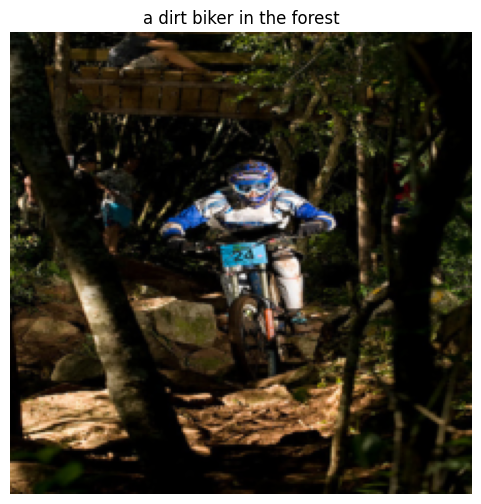

In [ ]:
import matplotlib.pyplot as plt
import torch

# Undo ImageNet normalization for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

img = imgs[0] * std + mean
img = img.clamp(0, 1).permute(1, 2, 0).numpy()

caption = " ".join(
    vocab.itos[i]
    for i in captions[0].tolist()
    if i not in (vocab.stoi["<PAD>"], vocab.stoi["<SOS>"], vocab.stoi["<EOS>"])
)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(caption)
plt.show()

In [ ]:
train_imgs = set(train_loader.dataset.df["image_id"])
val_imgs = set(val_loader.dataset.df["image_id"])
test_imgs = set(test_loader.dataset.df["image_id"])

assert train_imgs.isdisjoint(val_imgs), "TRAIN/VAL leak!"
assert train_imgs.isdisjoint(test_imgs), "TRAIN/TEST leak!"
assert val_imgs.isdisjoint(test_imgs), "VAL/TEST leak!"

print(f"OK: no image leaks across splits.")
print(f"  Train images: {len(train_imgs)}")
print(f"  Val   images: {len(val_imgs)}")
print(f"  Test  images: {len(test_imgs)}")

OK: no image leaks across splits.
  Train images: 6400
  Val   images: 800
  Test  images: 800
